# 02 — Signal to Image

Walks through the Phase 3/4 pipeline on a single record: baseline removal → bandpass → artifact clipping → robust normalization → windowing → waveform/STFT/CWT image generation. Then compares an apnea (`A`) window against a normal (`N`) window.

This is for interactive exploration. The full 70-record batch pipelines are `src/build_dataset.py` (Phase 3) and `src/build_images.py` (Phase 4) — run those from the terminal for the complete dataset; this notebook only processes a couple of example records so cells run in seconds.

*Educational project only — not a medical device or diagnostic tool.*

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Locate the project root (the directory containing config.yaml) regardless
# of whether Jupyter's cwd is the repo root or notebooks/.
root = Path.cwd()
while not (root / "config.yaml").exists():
    root = root.parent
sys.path.insert(0, str(root))

from src.data_loader import load_config, load_record
from src.preprocessing import (
    bandpass_filter,
    clip_extreme_artifacts,
    extract_windows,
    remove_baseline_wander,
    robust_normalize,
)
from src.representations import generate_all_representations

cfg = load_config(root / "config.yaml")
cfg["data"]["raw_dir"] = str(root / cfg["data"]["raw_dir"])
cfg

{'seed': 42,
 'data': {'raw_dir': '/Users/akashkar/Desktop/sleep-apnea-detection/data/raw',
  'processed_dir': 'data/processed',
  'images_dir': 'data/images',
  'splits_dir': 'data/splits',
  'sampling_rate_hz': 100,
  'window_minutes': 1,
  'context_minutes': [-1, 0, 1],
  'learning_records': {'a': [1, 20], 'b': [1, 5], 'c': [1, 10]},
  'test_records': {'x': [1, 35]},
  'excluded_related_records': ['a01r',
   'a02r',
   'a03r',
   'a04r',
   'b01r',
   'c01r',
   'c02r',
   'c03r',
   'a01er',
   'a02er',
   'a03er',
   'a04er',
   'b01er',
   'c01er',
   'c02er',
   'c03er']},
 'preprocessing': {'bandpass_low_hz': 0.5,
  'bandpass_high_hz': 40.0,
  'clip_iqr_multiplier': 20},
 'image': {'size': [224, 224],
  'preprocessing_version': 'v2',
  'waveform_amplitude_clip': 20.0,
  'stft_nperseg': 256,
  'stft_db_clip': [-80, 0],
  'cwt_n_scales': 64,
  'cwt_wavelet': 'morl',
  'cwt_db_clip': [-40, 40]},
 'training': {'batch_size': 32, 'learning_rate': 0.0003}}

## Load a raw record

`a01` is a heavily apnea-affected record from the learning set — good for seeing both classes without hunting for rare events.

In [2]:
RECORD_ID = "a01"
rec = load_record(RECORD_ID, cfg)

print(f"record: {rec.record_id}")
print(f"fs: {rec.fs} Hz")
print(f"duration: {len(rec.signal) / rec.fs / 60:.1f} min")
print(f"annotations: {len(rec.annotations)} ({rec.annotations.count('A')} apnea, {rec.annotations.count('N')} normal)")

record: a01
fs: 100 Hz
duration: 492.8 min
annotations: 489 (470 apnea, 19 normal)


## Step 1 — Baseline wander removal

Cascaded median-filter detrending (~200ms then ~600ms windows) removes slow drift without the phase distortion a sharp high-pass IIR filter can introduce.

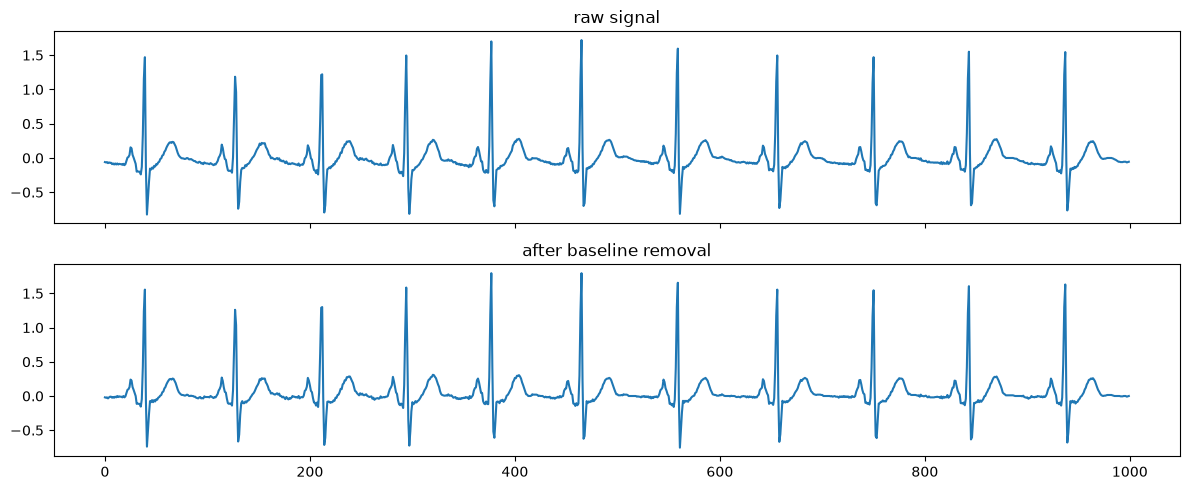

In [3]:
detrended = remove_baseline_wander(rec.signal, rec.fs)

seg = slice(0, 10 * rec.fs)  # first 10 seconds
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(rec.signal[seg])
axes[0].set_title("raw signal")
axes[1].plot(detrended[seg])
axes[1].set_title("after baseline removal")
plt.tight_layout()

## Step 2 — Bandpass filter

Zero-phase Butterworth bandpass (config: `preprocessing.bandpass_low_hz` / `bandpass_high_hz`) retains QRS/rhythm content and removes muscle noise and residual drift.

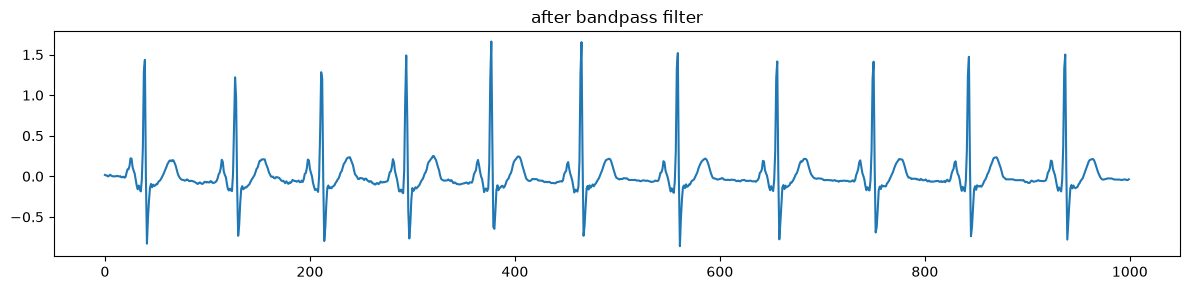

In [4]:
filtered = bandpass_filter(
    detrended,
    rec.fs,
    cfg["preprocessing"]["bandpass_low_hz"],
    cfg["preprocessing"]["bandpass_high_hz"],
)

plt.figure(figsize=(12, 3))
plt.plot(filtered[seg])
plt.title("after bandpass filter")
plt.tight_layout()

## Step 3 — Clip extreme artifacts, then robust-normalize

Percentile clipping doesn't work for ECG: normal R-peaks already occupy several percent of samples, so a percentile clip would cut into real QRS morphology. Instead we clip to `median ± clip_iqr_multiplier * IQR` — generous enough to leave normal beats untouched but tight enough to rein in genuine artifacts (we found filter-ringing spikes up to ~370 IQR in some records, e.g. around the saturation events in `x30`).

final signal range: [-17.95, 20.00] (median/IQR units)


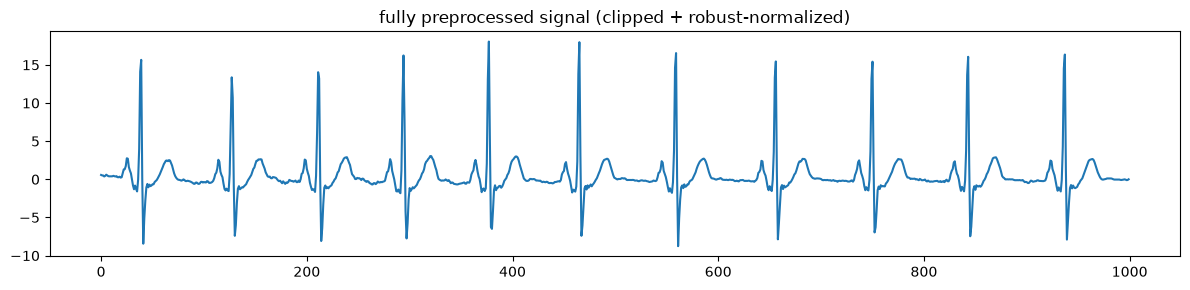

In [5]:
clipped = clip_extreme_artifacts(filtered, cfg["preprocessing"]["clip_iqr_multiplier"])
clean_signal = robust_normalize(clipped)

print(f"final signal range: [{clean_signal.min():.2f}, {clean_signal.max():.2f}] (median/IQR units)")

plt.figure(figsize=(12, 3))
plt.plot(clean_signal[seg])
plt.title("fully preprocessed signal (clipped + robust-normalized)")
plt.tight_layout()

## Step 4 — Window extraction

One window per annotated minute, with `context_minutes` of neighboring signal included. Windows are rejected (not silently modified) when context falls outside the record, the label isn't `A`/`N`, or more than 5% of the window is ADC-saturated.

In [6]:
windows = extract_windows(rec, cfg, clean_signal)

n_ok = sum(w.status == "ok" for w in windows)
n_rejected = len(windows) - n_ok
print(f"{len(windows)} windows total: {n_ok} accepted, {n_rejected} rejected")

reasons = {}
for w in windows:
    if w.status == "rejected":
        reasons[w.reason] = reasons.get(w.reason, 0) + 1
reasons

489 windows total: 488 accepted, 1 rejected


{'context_out_of_bounds': 1}

## Step 5 — Image representations

Waveform, STFT, and CWT for one accepted window. All three are deterministic, fixed-size, fixed-axis (no labels/legends/borders that could leak information to a model), and normalized against fixed config-driven bounds rather than per-image min/max, so images are comparable across records.

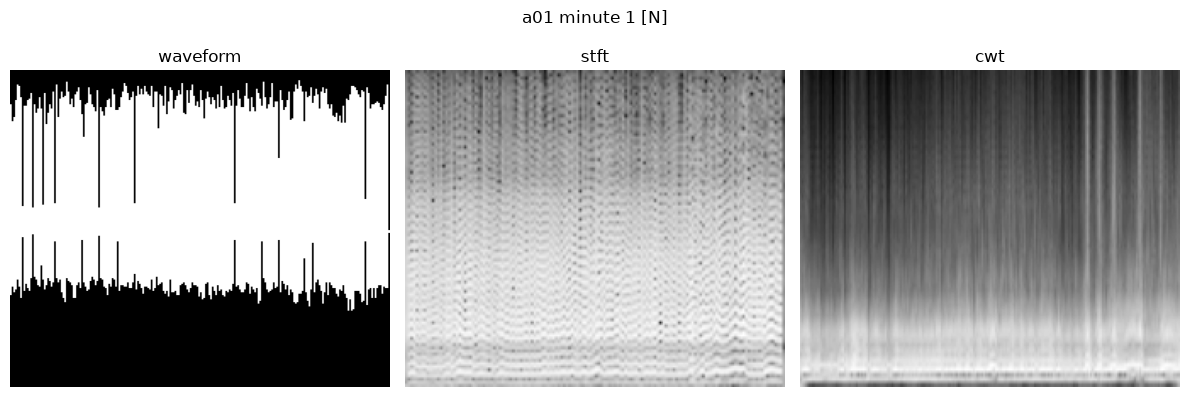

In [7]:
example = next(w for w in windows if w.status == "ok")
imgs = generate_all_representations(example.samples, rec.fs, cfg)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, img) in zip(axes, imgs.items()):
    ax.imshow(img, cmap="gray", aspect="auto")
    ax.set_title(name)
    ax.axis("off")
fig.suptitle(f"{RECORD_ID} minute {example.minute_index} [{example.label}]")
plt.tight_layout()

## Compare A vs N examples across records

`a01` is apnea-heavy, `c01` is entirely normal — pulling one window from each gives a clean side-by-side comparison.

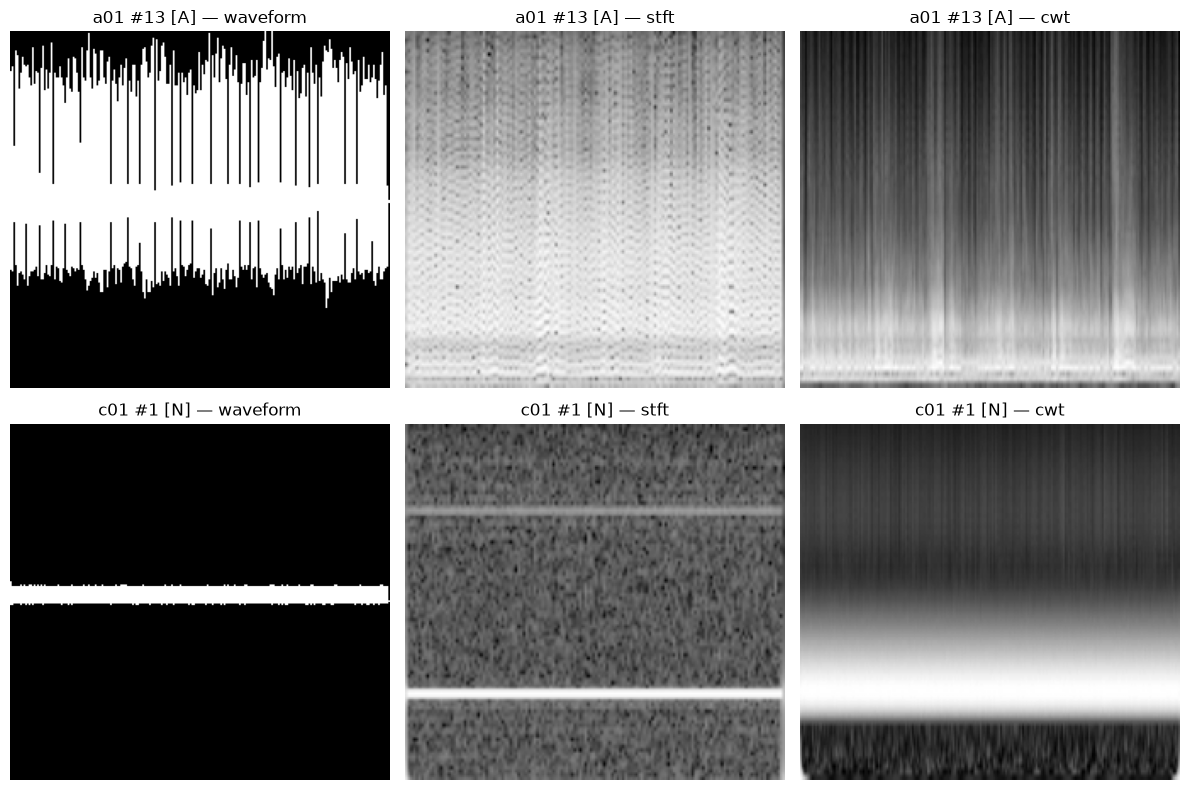

In [8]:
def preprocess_and_window(record_id: str):
    r = load_record(record_id, cfg)
    sig = robust_normalize(
        clip_extreme_artifacts(
            bandpass_filter(
                remove_baseline_wander(r.signal, r.fs),
                r.fs,
                cfg["preprocessing"]["bandpass_low_hz"],
                cfg["preprocessing"]["bandpass_high_hz"],
            ),
            cfg["preprocessing"]["clip_iqr_multiplier"],
        )
    )
    return r, extract_windows(r, cfg, sig)


examples = []
for record_id, wanted_label in [("a01", "A"), ("c01", "N")]:
    r, ws = preprocess_and_window(record_id)
    match = next(w for w in ws if w.status == "ok" and w.label == wanted_label)
    examples.append((r, match))

fig, axes = plt.subplots(len(examples), 3, figsize=(12, 4 * len(examples)))
for row, (r, w) in enumerate(examples):
    imgs = generate_all_representations(w.samples, r.fs, cfg)
    for col, (name, img) in enumerate(imgs.items()):
        axes[row, col].imshow(img, cmap="gray", aspect="auto")
        axes[row, col].set_title(f"{r.record_id} #{w.minute_index} [{w.label}] — {name}")
        axes[row, col].axis("off")
plt.tight_layout()

## Notes

- The waveform image compresses a `window_minutes + context_minutes` segment (3 minutes at the default config, 18,000 samples at 100 Hz) into a 224px-wide image — about 80 samples per pixel. That's far too coarse to show individual QRS shapes; what you're actually seeing is the amplitude *envelope* over time, which still carries heart-rate/rhythm-density information relevant to apnea (unlike arrhythmia classification, where individual beat morphology matters more). Phase 5's planned representation comparison will show empirically whether this envelope view, the STFT, or the CWT carries the most signal for this task.
- `data_quality_report.md` and `preprocessing_report.md` in `reports/` have the full per-record numbers (sampling rate, clipping, class balance, rejection reasons) this notebook only samples from.
- To (re)generate the full dataset, run from the repo root: `uv run python -m src.build_dataset` then `uv run python -m src.build_images`.